# Principal Component Analysis (PCA) of Handwritten Digits

This notebook demonstrates PCA application on the sklearn digits dataset,
which contains 1,797 8x8 grayscale images of handwritten digits (0-9).
The analysis shows how PCA can be used for dimensionality reduction
and visualization of high-dimensional image data.

The notebook visualizes:
1. An example digit image
2. The first two principal components
3. A scatter plot of digits projected onto these components

## Loading the Dataset

The digits dataset contains 1,797 samples, each a flattened 8×8 grayscale image (64 features)
of a handwritten digit from 0 to 9.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load the digits dataset
digits = load_digits()
digits_images = digits.data    # 1797 images, each 8x8 pixels (64 features)
digits_labels = digits.target  # corresponding digit labels (0-9)
print(digits_images.shape)

(1797, 64)


## Visualising a Sample Digit

Each sample is stored as a flat vector of 64 values. We reshape it back to 8×8 to display it as an image.

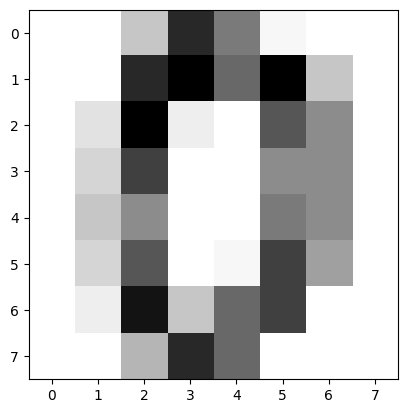

In [2]:
# Display an example digit
index = 0
digit = digits_images[index,:].reshape(8,8)  # reshape to 8x8 image
plt.imshow(digit, cmap='Greys')
plt.show()

## Performing PCA

PCA finds the directions of maximum variance in the dataset. Each principal component is a
64-dimensional vector that can be reshaped into an 8×8 "eigendigit" image.

In [3]:
# Perform PCA
pca = PCA()  # initialize PCA object
pca.fit(digits_images)

# Extract principal components
principal_components = pca.components_.T  # each column is a principal component

## Visualising the First Two Principal Components

The first principal component captures the direction of greatest variance, the second captures
the next greatest orthogonal direction. Visualised as images they reveal which pixel patterns
vary most across the dataset.

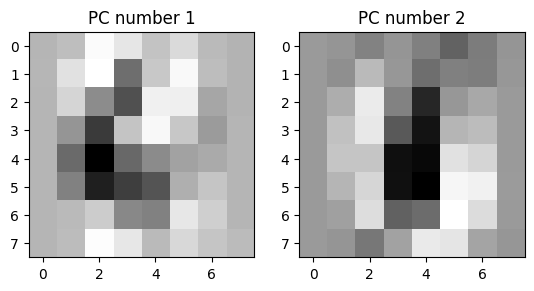

In [4]:
# Visualize first two principal components
fig, axs = plt.subplots(1,2)
axs[0].imshow(principal_components[:,0].reshape(8,8), cmap='Greys')
axs[0].set_title('PC number 1')
axs[1].imshow(principal_components[:,1].reshape(8,8), cmap='Greys')
axs[1].set_title('PC number 2')
plt.show()

## Projecting Data onto Principal Components

Projecting each image onto the first two PCs gives a 2D coordinate for each sample.
Colouring points by their digit label shows how well the two components separate the classes.

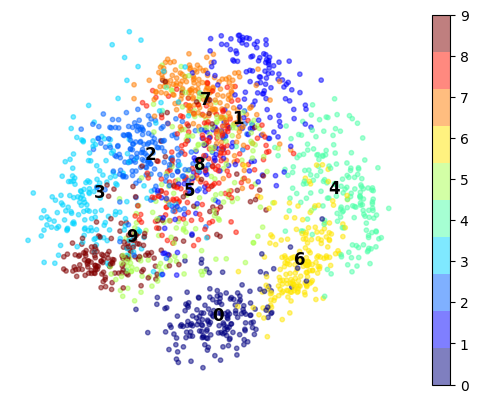

In [5]:
# Project data onto principal components
# Subtract the mean before projecting (PCA was fitted on centred data)
pca_scores = (digits_images - pca.mean_) @ principal_components

# Create scatter plot of digits in PC space
plt.scatter(pca_scores[:,0], pca_scores[:,1],  # plot first two PCs
          c=digits_labels,  # color by digit
          alpha=0.5,  # transparency
          s=10,  # point size
          cmap=plt.colormaps['jet'].resampled(10))  # colormap with 10 discrete colors

# Add number text at the mean position of each digit in PC space
for digit in range(10):
    mean_x = np.mean(pca_scores[digits_labels == digit, 0])
    mean_y = np.mean(pca_scores[digits_labels == digit, 1])
    plt.text(mean_x, mean_y, str(digit), fontsize=12, fontweight="bold",
             ha="center", va="center", color="black")

plt.colorbar()
plt.axis("off")
plt.show()